# Árboles de decisión
Los **árboles de decisión** son modelos predictivos utilizados tanto para tareas de clasificación como de regresión en el aprendizaje supervisado. Su estructura se asemeja a un árbol, donde cada nodo interno representa una pregunta o condición sobre una variable de entrada, cada rama corresponde a una respuesta posible, y cada hoja representa una predicción o resultado final.

Su nombre proviene de su estructura, que se asemeja a un diagrama de flujo o un árbol invertido, y se utiliza tanto para problemas de clasificación como de regresión.

Un árbol de decisión divide recursivamente el espacio de características en regiones homogéneas respecto a la variable objetivo. El proceso de construcción consiste en seleccionar, en cada nodo, la variable y el umbral que mejor separan los datos según algún criterio de pureza (por ejemplo, *Gini*, *entropía* para clasificación, o *varianza* para regresión).

Los modelos de árboles de decisión se engloban dentro de una clase conocida como algoritmos **CART** (Classification and Regression Trees).

**Concepto y Estructura: La Lógica de la Pregunta**

El objetivo principal de un Árbol de Decisión es aprender una secuencia de preguntas tipo "SI ESTO, ENTONCES AQUELLO" que conduzcan a la predicción correcta de la manera más eficiente posible. El algoritmo construye esta estructura jerárquica dividiendo el conjunto de datos de entrada en subconjuntos cada vez más "puros" o homogéneos.

### Elementos Clave del Árbol

La estructura de un árbol permite representar una lógica de decisión clara:

| Elemento | Descripción |
|---|---|
| **Nodo Raíz** (Root Node) | El punto de partida que contiene todo el conjunto de datos. La primera división importante se realiza aquí. |
| **Nodos de Decisión** (Decision Nodes) | Puntos intermedios donde se evalúa una condición o "test" sobre un atributo (p. ej., "¿Es la Edad menor que 12?"). |
| **Ramas/Sub-árboles** | Conectan los nodos de decisión y representan el camino que se toma al responder la pregunta. |
| **Nodos Terminales** o **Hojas** (Leaf Nodes) | Los nodos finales que no se dividen más. Contienen la predicción final o la etiqueta de clasificación (p. ej., "Sobrevive" o "No Sobrevive"). |


### Funcionamiento: La Búsqueda de la Pureza

Cuando el algoritmo construye el árbol, debe decidir, entre todos los atributos de entrada (como edad, sexo, ingreso, etc.), cuál es el mejor para dividir los datos en cada etapa. El "mejor" atributo es aquel que logra la partición más limpia o pura, minimizando la incertidumbre sobre la categoría de la salida.

Para lograr esto, el algoritmo utiliza medidas de **impureza** para evaluar la calidad de cada posible división. Las dos métricas más comunes son el **Índice de Gini** y la **Ganancia de Información** (basada en Entropía)

### Modelo Matemático: El Índice de Gini

El Índice de Gini mide la probabilidad de que un elemento elegido al azar de un subconjunto sea clasificado incorrectamente si su clase se selecciona aleatoriamente en proporción a la distribución de clases en ese subconjunto.

• Objetivo: El algoritmo busca elegir divisiones que **minimicen** el Índice de Gini. Un valor de 0 indica una pureza total (todos los elementos pertenecen a una sola clase), mientras que un valor más cercano a 1 (o 0.5 para clasificación binaria) indica una mezcla de clases.

El Índice de Gini se calcula mediante la siguiente fórmula:
$$
Gini=1− \sum_{i=1} ^n (p_{i})^2
$$

Argumentos de la Fórmula:

- $n$: La cantidad de clases posibles (p. ej., si el problema es binario, n=2).

- $p_{i}$ : La probabilidad (o proporción) de que un objeto pertenezca a la clase particular $i$.

- Proceso: Al calcular el Gini para cada posible división, el algoritmo elige la característica y el valor de corte que resulten en la mayor reducción de la impureza (es decir, el menor valor de Gini ponderado en los nodos hijos)

### **Formalización matemática:**

Para clasificación, el árbol busca particiones que minimicen una función de impureza $I$ en cada nodo $t$:

$$
I(t) = \sum_{k=1}^K p_{k}(1 - p_{k})
$$

donde $p_{k}$ es la proporción de muestras de la clase $k$ en el nodo $t$ (índice de Gini).  
Para regresión, se suele minimizar la suma de los errores cuadrados (varianza):

$$
I(t) = \frac{1}{N_t} \sum_{i \in t} (y_i - \bar{y}_t)^2
$$

donde $N_t$ es el número de muestras en el nodo $t$ y $\bar{y}_t$ es el valor medio de la variable objetivo en ese nodo.

El árbol se construye de manera recursiva hasta que se cumple un criterio de parada (profundidad máxima, número mínimo de muestras, etc.).

## Ventajas 
**Fácil Interpretación**: Pueden visualizarse como diagramas de flujo simples, lo que facilita explicar el resultado a personas sin conocimientos técnicos.

**No Paramétrico**: No se hacen suposiciones sobre la distribución subyacente de los datos.

**Rápido**: Son relativamente rápidos de entrenar y de usar para predecir nuevos datos.

**Manejo de Datos**: Pueden manejar datos categóricos y numéricos eficientemente y son útiles incluso con conjuntos de datos incompletos.

## Desventajas
**Propenso al Sobreajuste (Overfitting)**: Si el árbol crece demasiado (mucha profundidad), puede memorizar el ruido y los detalles específicos del conjunto de entrenamiento y fallar al generalizar.

**Sensibilidad**: Pequeños cambios en los datos de entrada pueden causar grandes cambios en la estructura del árbol, afectando las predicciones.

**No Globalmente Óptimo**: Los árboles se construyen utilizando una estrategia "voraz" (greedy), lo que significa que eligen la mejor división localmente, pero esto no garantiza que la estructura final sea la mejor globalmente.

**Fronteras de Decisión**: Tienden a crear fronteras de decisión cuadradas o rectilíneas, lo que puede ser ineficiente para modelar relaciones no lineales suaves.

#### Ejemplo de uso en Python (clasificación):
Un ejemplo clásico es predecir la supervivencia en el desastre del Titanic, donde las decisiones se basan en atributos discretos y continuos como la edad y el sexo.

Utilizamos la librería scikit-learn en Python para construir el árbol. En este ejemplo, el árbol se entrena para decidir si un pasajero sobrevive (Sí) o no (No), basándose en el sexo y la edad.

1. **Preparación de Datos**: Se definen los atributos de entrada (X) y el resultado esperado (y). (Asumimos que 'Sex_male' ha sido codificado como 0 o 1).
2. **Construcción y Entrenamiento**: Se importa la clase DecisionTreeClassifier y se ajusta el modelo a los datos de entrenamiento

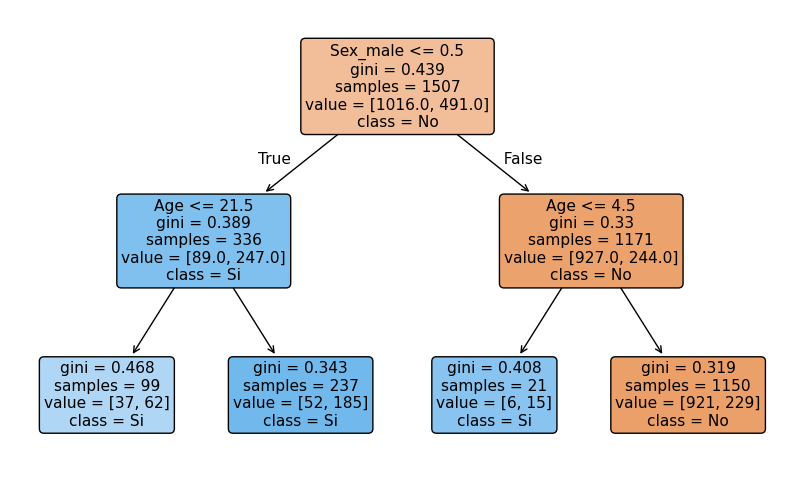

In [5]:
# EJEMPLO CONCEPTUAL EN PYTHON USANDO SCIKIT-LEARN

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

df = pd.read_csv('https://patricioaraneda.cl/public/titanic5_full.csv')
df = df[['Survived', 'Age', 'Sex']].dropna(subset=['Survived', 'Age', 'Sex'])

# Codificar sexo (male=1, female=0)
# Si 'Sex' ya está codificado como 0/1, el mapeo dará NaN; rellenamos con el valor original en ese caso.
df['Sex_male'] = df['Sex'].map({'male': 1, 'female': 0})
df['Sex_male'] = df['Sex_male'].fillna(df['Sex']).astype(float)

# Simulación de datos: [Edad, Sexo (1=Masculino, 0=Femenino)]
# En un caso real, esto provendría del dataset de Titanic
X_data = df[['Age', 'Sex_male']].values
# Etiquetas: 1=Sobrevive, 0=No Sobrevive
y_labels = df['Survived'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(X_data, y_labels, test_size=0.3, random_state=42)

# --- Crear y Entrenar el Modelo ---
# Limitamos la profundidad para evitar el sobreajuste (max_depth=2) [15]
clf = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=0)
clf.fit(X_train, y_train) 

# --- Visualización del Árbol ---
# plot_tree fue importado de sklearn.tree arriba.
plt.figure(figsize=(10,6))
# X_data es un numpy.ndarray, no tiene .columns => pasamos los nombres de las características explícitamente
plot_tree(clf, feature_names=['Age', 'Sex_male'], class_names=['No', 'Si'], filled=True, rounded=True)
plt.show()
# Esta función generaría un diagrama donde se ve:
# 1. El nodo raíz dividiendo por 'Sex_male' (porque es el atributo más importante, como se ve en el ejemplo real).
# 2. Las siguientes divisiones basadas en 'Age'.

Accuracy: 0.7650695517774343
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       437
           1       0.69      0.50      0.58       210

    accuracy                           0.77       647
   macro avg       0.74      0.70      0.71       647
weighted avg       0.76      0.77      0.75       647

Age: 0.1783
Sex_male: 0.8217


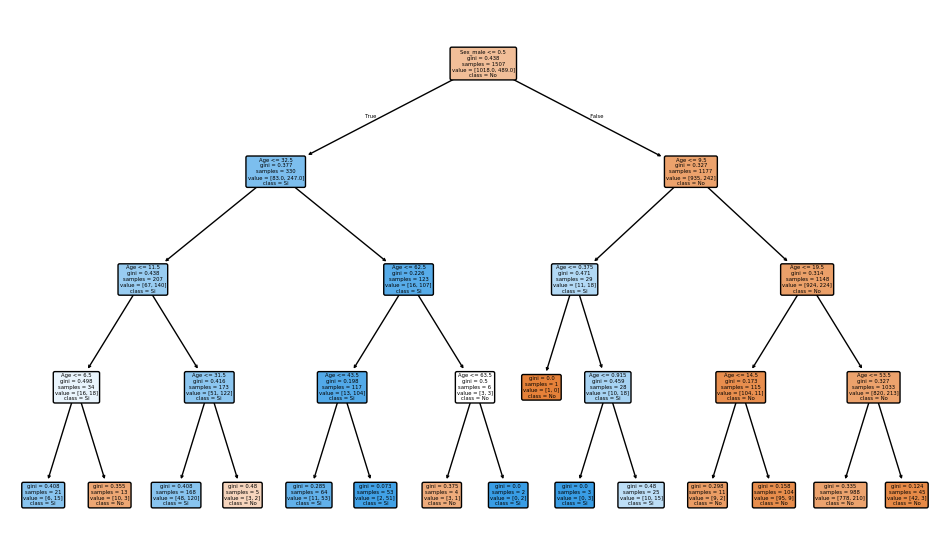

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Cargar y preparar datos
import requests

df = pd.read_csv('https://patricioaraneda.cl/public/titanic5_full.csv')
df = df[['Survived', 'Age', 'Sex']].dropna(subset=['Survived', 'Age', 'Sex'])

# Codificar sexo (male=1, female=0)
df['Sex_male'] = df['Sex'].map({'male': 1, 'female': 0})

# Características y etiqueta
X_t = df[['Age', 'Sex_male']].values
y_t = df['Survived'].astype(int).values

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X_t, y_t, test_size=0.3, random_state=42, stratify=y_t)

# Entrenar árbol de decisión
clf = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=0)
clf.fit(X_train, y_train)

# Evaluación
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# importancia de características
importances = clf.feature_importances_
feature_names = ['Age', 'Sex_male']
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")


# Visualizar árbol

plt.figure(figsize=(12,7))
plot_tree(clf, feature_names=['Age','Sex_male'], class_names=['No','Si'], filled=True, rounded=True)
plt.show()
# El árbol resultante mostraría cómo las decisiones se basan en estos atributos para predecir la supervivencia

### Prediccion sobre arbol de decisión

In [7]:
# genera una predicion para un pasajero de 25 años y sexo masculino
sample_passenger = np.array([[25, 1]])  # 25 años, masculino
predicted_survival = clf.predict(sample_passenger)
print(f"Predicción de supervivencia para pasajero de 25 años y sexo masculino: {'Sobrevive' if predicted_survival[0] == 1 else 'No Sobrevive'}")

Predicción de supervivencia para pasajero de 25 años y sexo masculino: No Sobrevive


In [8]:
# genera predicciones para pasajeros con diferentes edades y sexos
sample_passengers = np.array([[22, 0],  # 22 años, masculino
                              [30, 1],  # 30 años, femenino
                              [40, 1],  # 40 años, masculino
                              [35, 0]]) # 25 años, femenino
predicted_survivals = clf.predict(sample_passengers)
print("Predicciones de supervivencia para pasajeros de diferentes edades y sexos:")
for i, passenger in enumerate(sample_passengers):
    age, sex = passenger
    survival = 'Sobrevive' if predicted_survivals[i] == 1 else 'No Sobrevive'
    print(f"{age} años y sexo {'masculino' if sex == 1 else 'femenino'}: {survival}")


Predicciones de supervivencia para pasajeros de diferentes edades y sexos:
22 años y sexo femenino: Sobrevive
30 años y sexo masculino: No Sobrevive
40 años y sexo masculino: No Sobrevive
35 años y sexo femenino: Sobrevive


#### Ejemplo de uso en Python (regresión):

In [9]:
from sklearn.tree import DecisionTreeRegressor

# Datos de ejemplo

X = np.array([[1], [2], [3], [4], [5]])
y = np.array([1.2, 1.9, 3.0, 3.9, 5.1])

# Entrenamiento del árbol

reg = DecisionTreeRegressor()
reg.fit(X, y)

# Predicción

print(reg.predict([[3.5]]))  # Salida aproximada: [3.0 o 3.9]

[3.]


## Aplicaciones comunes

- Diagnóstico médico (clasificación de enfermedades)
- Detección de fraude
- Predicción de abandono de clientes (*churn*)
- Segmentación de clientes en marketing
- Predicción de precios de viviendas (regresión)

Los árboles de decisión son la base de algoritmos más avanzados como Random Forest y Gradient Boosting. Su principal ventaja es la interpretabilidad y facilidad de visualización, aunque pueden sobreajustar si no se podan o regulan adecuadamente.

---

# Random Forest

El **Random Forest** es un algoritmo de aprendizaje supervisado basado en el **ensamblado de múltiples árboles de decisión** combinando las predicciones de múltiples árboles individuales para generar un resultado final más preciso y robusto. Su objetivo es mejorar la precisión y robustez de las predicciones, tanto en tareas de clasificación como de regresión, reduciendo el sobreajuste (*overfitting*) que suelen presentar los árboles individuales.

El algoritmo de Random Forest surgió como una solución directa para mitigar una limitación clave de los Árboles de Decisión individuales: la propensión al sobreajuste (overfitting). Un solo árbol, si se le permite crecer con suficiente profundidad, puede memorizar los datos de entrenamiento (incluyendo su ruido) en lugar de aprender a generalizar la relación subyacente.

Al crear muchos árboles que trabajan en conjunto, el modelo se vuelve menos sensible a los datos ruidosos, logrando una mayor precisión y una notable resistencia al sobreajuste.

El éxito de Random Forest se basa en introducir intencionalmente una "doble aleatoriedad" durante el proceso de entrenamiento de cada árbol individual, asegurando que cada uno desarrolle una perspectiva ligeramente diferente del problema.

**¿Cómo funciona?**
- Construye un conjunto (o "bosque") de árboles de decisión independientes, cada uno entrenado sobre una muestra aleatoria (con reemplazo, *bootstrap*) de los datos originales.

- En cada nodo de cada árbol, la selección de la variable para dividir se realiza considerando solo un subconjunto aleatorio de las variables disponibles, lo que introduce diversidad entre los árboles.

- Para clasificación, cada árbol vota por una clase y la predicción final es la clase más votada (mayoría). Para regresión, se promedian las predicciones de todos los árboles.

**Ventajas principales:**
- Generalmente ofrece mayor precisión que un solo árbol de decisión.
- Es robusto frente al ruido y al sobreajuste.
- Puede manejar grandes cantidades de variables y datos.
- Permite estimar la importancia de cada variable en la predicción.

**Desventajas:**
- Menor interpretabilidad que un árbol único.
- Puede ser computacionalmente costoso con muchos árboles y datos muy grandes.

**Aplicaciones comunes:**  
Detección de fraudes, diagnóstico médico, clasificación de imágenes, predicción de abandono de clientes, análisis de crédito, entre otros.

**Resumen:**  
Random Forest es una técnica poderosa y versátil, ampliamente utilizada en la industria y la investigación por su capacidad para ofrecer predicciones precisas y estables en una amplia variedad de problemas.

## Los pasos para construir un Random Forest son:
### A. Muestreo de Datos (Bootstrapping)
En lugar de entrenar cada árbol con el conjunto de datos completo, el algoritmo utiliza una técnica llamada "muestreo de bolsa" o "bootstrapping".

Esto implica:

1. Se toma un subconjunto aleatorio del conjunto de datos original.
2. Este subconjunto se utiliza para entrenar un árbol individual.
3. Este proceso se repite, creando muchos árboles, cada uno basado en un subconjunto de datos ligeramente diferente

### B. Selección Aleatoria de Características
Cuando un árbol de decisión se está construyendo (definiendo sus nodos de división), normalmente buscaría la mejor división entre todas las características disponibles. Random Forest añade una capa extra de aleatoriedad:

1. Si el conjunto total de atributos es m, en cada división, el algoritmo solo considera un subconjunto aleatorio de k características (donde k < m).

2. El árbol debe elegir la mejor división dentro de este subconjunto limitado.
Esta variación constante en los datos de entrenamiento y las características utilizadas reduce la correlación entre los árboles y mejora la precisión general del modelo.

3. Predicción y Agregación
Una vez que se ha construido el "bosque" de n árboles, el algoritmo combina sus salidas para obtener una predicción robusta:

- **Para problemas de Clasificación**: Cada árbol "vota" por una clase. La predicción final se determina por la mayoría de los votos emitidos por todos los árboles.

- **Para problemas de Regresión**: Las salidas de todos los árboles se promedian para determinar el valor predicho final.

Accuracy (RF): 0.9580
ROC AUC (RF): 0.9950

Classification Report (RF):
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143

Confusion Matrix (RF):
[[49  4]
 [ 2 88]]
OOB Score: 0.9624


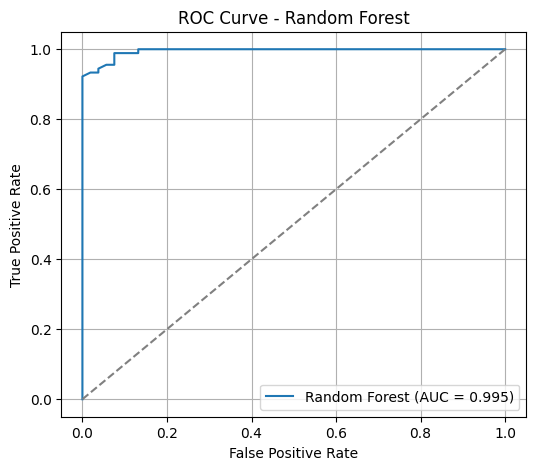

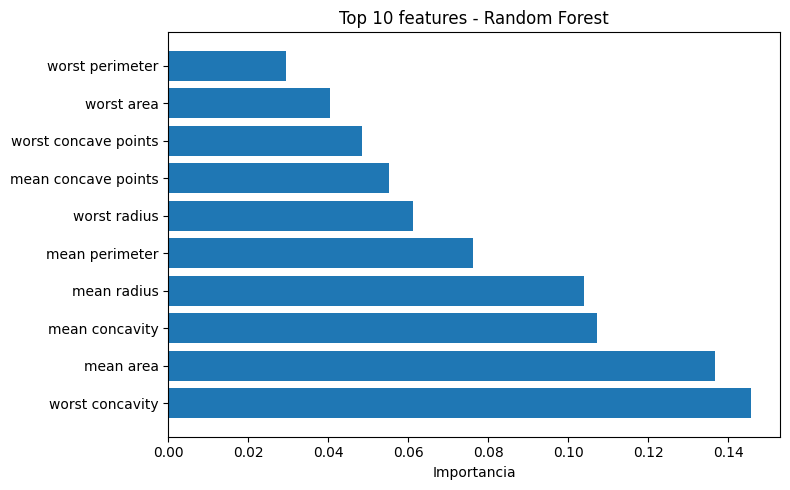

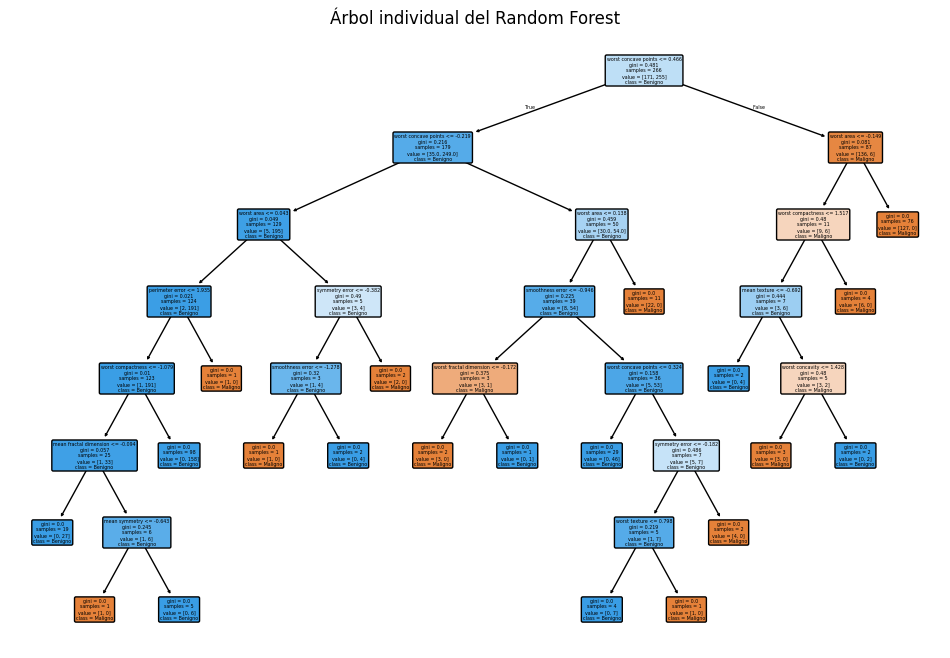

In [10]:
# Random Forest - clasificación sobre el dataset breast cancer (sklearn)
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
data = load_breast_cancer()
X_bc = data.data
y_bc = data.target
feature_names = data.feature_names

# División train/test
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.25, random_state=42, stratify=y_bc
)

# Escalado (opcional pero recomendado para muchos modelos)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_bc)
X_test_s = scaler.transform(X_test_bc)

# Definir y entrenar el modelo
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)
rf_clf.fit(X_train_s, y_train_bc)

# Predicción y probabilidades
y_pred_rf = rf_clf.predict(X_test_s)
y_proba_rf = rf_clf.predict_proba(X_test_s)[:, 1]

# Métricas de evaluación
acc_rf = accuracy_score(y_test_bc, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test_bc, y_proba_rf)

print(f"Accuracy (RF): {acc_rf:.4f}")
print(f"ROC AUC (RF): {roc_auc_rf:.4f}")
print("\nClassification Report (RF):")
print(classification_report(y_test_bc, y_pred_rf))
print("Confusion Matrix (RF):")
print(confusion_matrix(y_test_bc, y_pred_rf))
if hasattr(rf_clf, "oob_score_"):
    print(f"OOB Score: {rf_clf.oob_score_:.4f}")

# Curva ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test_bc, y_proba_rf)
plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(True)
plt.show()

# Importancia de características (top 10)
importances_rf = rf_clf.feature_importances_
idxs_rf = np.argsort(importances_rf)[::-1][:10]
top_feats_rf = feature_names[idxs_rf]
top_vals_rf = importances_rf[idxs_rf]

plt.figure(figsize=(8,5))
plt.barh(np.arange(len(top_feats_rf))[::-1], top_vals_rf[::-1], align='center')
plt.yticks(np.arange(len(top_feats_rf)), top_feats_rf[::-1])
plt.xlabel('Importancia')
plt.title('Top 10 features - Random Forest')
plt.tight_layout()
plt.show()

# visualización de un árbol individual del bosque
plt.figure(figsize=(12,8))
plot_tree(rf_clf.estimators_[0], feature_names=feature_names, class_names=['Maligno', 'Benigno'], filled=True, rounded=True)
plt.title('Árbol individual del Random Forest')
plt.show()

Accuracy: 0.768160741885626
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       437
           1       0.69      0.52      0.59       210

    accuracy                           0.77       647
   macro avg       0.74      0.70      0.72       647
weighted avg       0.76      0.77      0.76       647



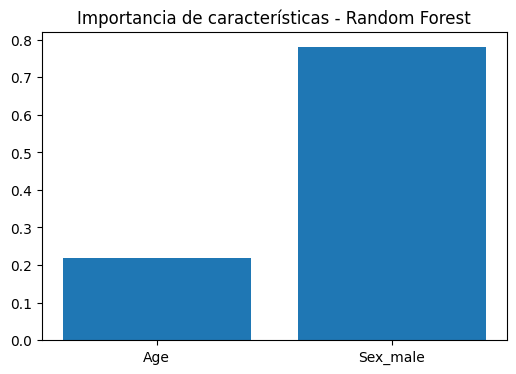

In [12]:
# Random Forest - clasificación sobre el dataset titanic
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Cargar y preparar datos
import requests

df = pd.read_csv('https://patricioaraneda.cl/public/titanic5_full.csv')
df = df[['Survived', 'Age', 'Sex']].dropna(subset=['Survived', 'Age', 'Sex'])
# Codificar sexo (male=1, female=0)
df['Sex_male'] = df['Sex'].map({'male': 1, 'female': 0})
# Características y etiqueta
X_t = df[['Age', 'Sex_male']].values
y_t = df['Survived'].astype(int).values
# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X_t, y_t, test_size=0.3, random_state=42, stratify=y_t)
# Entrenar Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=0)
rf_clf.fit(X_train, y_train)
# Evaluación
y_pred = rf_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
# Importancia de características
importances = rf_clf.feature_importances_
feature_names = ['Age', 'Sex_male']
plt.figure(figsize=(6,4))
plt.bar(feature_names, importances)
plt.title('Importancia de características - Random Forest')
plt.show()  


In [13]:
# genera predicciones para pasajeros con diferentes edades y sexos
sample_passengers = np.array([[22, 0],  # 22 años, masculino
                              [30, 1],  # 30 años, femenino
                              [40, 1],  # 40 años, femenino
                              [35, 0]]) # 35 años, masculino
predictions = rf_clf.predict(sample_passengers)
print("Predicciones de supervivencia para pasajeros de diferentes edades y sexos:")
for i, passenger in enumerate(sample_passengers):
    age, sex = passenger
    survival = 'Sobrevive' if predictions[i] == 1 else 'No Sobrevive'
    print(f"{age} años y sexo {'masculino' if sex == 1 else 'femenino'}: {survival}")

Predicciones de supervivencia para pasajeros de diferentes edades y sexos:
22 años y sexo femenino: Sobrevive
30 años y sexo masculino: No Sobrevive
40 años y sexo masculino: No Sobrevive
35 años y sexo femenino: Sobrevive


---

# Gradient Boosting

El **Gradient Boosting** (Impulso de Gradiente) es una técnica de ensamblado (*ensemble*) utilizada en machine learning para construir modelos predictivos potentes a partir de la combinación secuencial de modelos débiles, generalmente árboles de decisión poco profundos. El objetivo es mejorar la precisión corrigiendo los errores cometidos por los modelos anteriores en cada iteración.

Este algoritmo pertenece a la clase de modelos basados en árboles (Tree-Based) y se utiliza tanto para problemas de clasificación como de regresión.

La característica distintiva del gradient boosting es su enfoque de **ensamblado secuencial**, a diferencia de otros métodos (como Random Forest) que construyen modelos en paralelo.

1. **Construcción Serial**: Los árboles de decisión se construyen uno tras otro.
**
2. **Corrección de Errores: Cada nuevo árbol que se añade al modelo intenta corregir los errores o las debilidades del árbol construido inmediatamente anterior.

3. **Minimización de la Pérdida**: El método utiliza el concepto de **gradiente** (que es la pendiente de una función) para determinar la dirección en la que deben ajustarse los parámetros del modelo, con el objetivo de minimizar la función de pérdida. Este proceso es similar a cómo el algoritmo de Descenso de Gradiente (Gradient Descent) se utiliza en redes neuronales para optimizar los pesos.

## Parámetros y Ventajas
Los modelos de gradient boosting suelen utilizar árboles poco profundos (a menudo con una profundidad máxima de uno a cinco niveles) y dependen de una fuerte pre-poda, en lugar de la aleatoriedad, para controlar la complejidad.

Dos parámetros clave para sintonizar este modelo son:
- **Learning Rate (Tasa de Aprendizaje)**: Este parámetro es crucial porque controla la fuerza con la que cada nuevo árbol intenta corregir los errores cometidos por los árboles anteriores.

- **n_estimators (Número de Estimadores)**: Representa la cantidad de árboles que se construirán en la secuencia.

Los algoritmos de gradient boosting se encuentran frecuentemente entre las soluciones ganadoras de las competiciones de aprendizaje automático y se utilizan ampliamente en la industria debido a su alta precisión.


### Definición matemática: 
Gradient Boosting busca minimizar una función de pérdida $L(y, F(x))$ (por ejemplo, el error cuadrático para regresión o la log-loss para clasificación) mediante la construcción de un modelo aditivo:

$$
F_{m}(x) = F_{m-1}(x) + \gamma_m h_m(x)
$$

donde:
- $F_{m}(x)$ es el modelo en la iteración $m$,
- $F_{m-1}(x)$ es el modelo anterior,
- $h_m(x)$ es el nuevo modelo débil (por ejemplo, un árbol de decisión),
- $\gamma_m$ es el peso (tasa de aprendizaje) asignado a $h_m(x)$.

En cada iteración, $h_m(x)$ se ajusta para aproximar el gradiente negativo de la función de pérdida respecto a las predicciones actuales, es decir, el error residual:

$$
r_{im} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x) = F_{m-1}(x)}
$$

El nuevo modelo $h_m(x)$ se entrena para predecir estos residuos.

**Ejemplo de uso en Python (regresión):**

In [14]:
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

# Datos de ejemplo
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 5, 4, 5])

# Entrenamiento del modelo Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2)
gb.fit(X, y)

# Predicción
y_pred = gb.predict(X)
print("Predicciones:", y_pred)

Predicciones: [2.00411646 4.00125883 4.99461973 4.00475908 4.9952459 ]


**Aplicaciones comunes:**  
Gradient Boosting se utiliza ampliamente en tareas de regresión y clasificación, como predicción de precios, scoring crediticio, detección de fraudes y competiciones de ciencia de datos (por ejemplo, XGBoost, LightGBM y CatBoost son variantes populares). Su fortaleza radica en su alta precisión y capacidad para manejar datos heterogéneos y relaciones complejas.

Ejemplo de clasificacion con gradient boosting (breast cancer)

Accuracy: 0.958
ROC AUC: 0.995

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.91      0.94        53
           1       0.95      0.99      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143

Confusion Matrix:
 [[48  5]
 [ 1 89]]


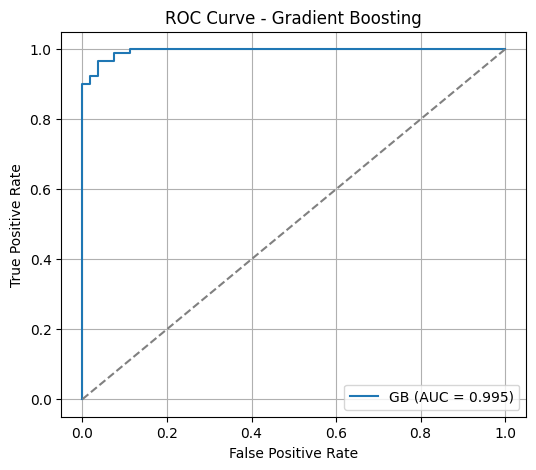

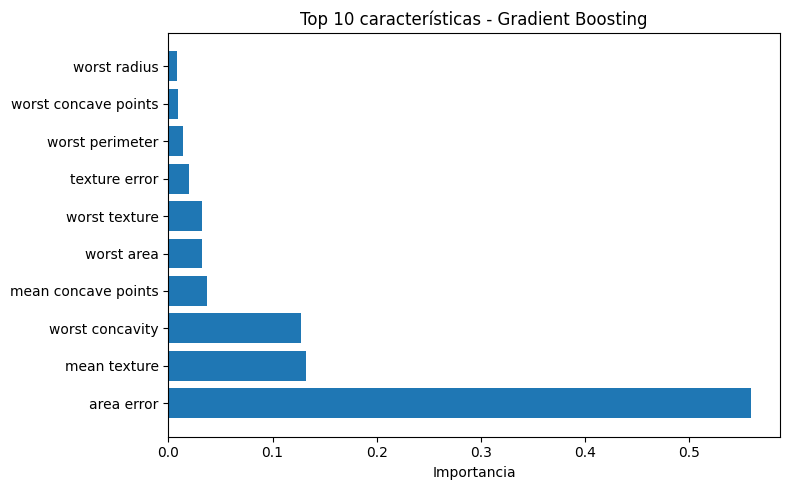

In [15]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import numpy as np
import pandas as pd

# Gradient Boosting (clasificación) con un dataset clásico: Breast Cancer
import matplotlib.pyplot as plt

# Cargar datos
data = load_breast_cancer()
X_bc = data.data
y_bc = data.target
feature_names = data.feature_names

# División train/test
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.25, random_state=42, stratify=y_bc
)

# Escalado (opcional pero recomendado para muchos modelos)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_bc)
X_test_s = scaler.transform(X_test_bc)

# Entrenar el modelo Gradient Boosting (clasificador)
gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_clf.fit(X_train_s, y_train_bc)

# Predicciones y evaluación
y_pred = gb_clf.predict(X_test_s)
y_proba = gb_clf.predict_proba(X_test_s)[:, 1]

print("Accuracy:", round(accuracy_score(y_test_bc, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test_bc, y_proba), 4))
print("\nClassification Report:\n", classification_report(y_test_bc, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_bc, y_pred))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test_bc, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'GB (AUC = {roc_auc_score(y_test_bc, y_proba):.3f})')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend()
plt.grid(True)
plt.show()

# Importancias de características (top 10)
importances = gb_clf.feature_importances_
idxs = np.argsort(importances)[::-1][:10]
top_feats = feature_names[idxs]
top_vals = importances[idxs]

plt.figure(figsize=(8,5))
plt.barh(np.arange(len(top_feats))[::-1], top_vals[::-1], align='center')
plt.yticks(np.arange(len(top_feats)), top_feats[::-1])
plt.xlabel('Importancia')
plt.title('Top 10 características - Gradient Boosting')
plt.tight_layout()
plt.show()

Ejemplo de regresion con gradient boosting (diabetes)

MSE: 3243.543    RMSE: 56.952    R2: 0.413


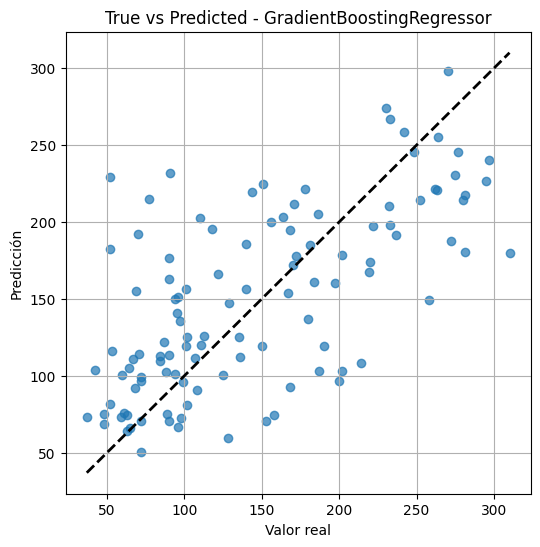

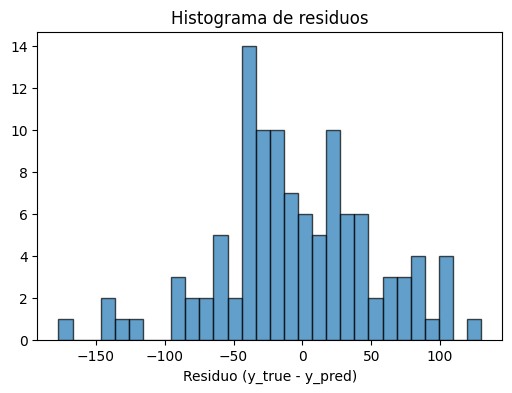

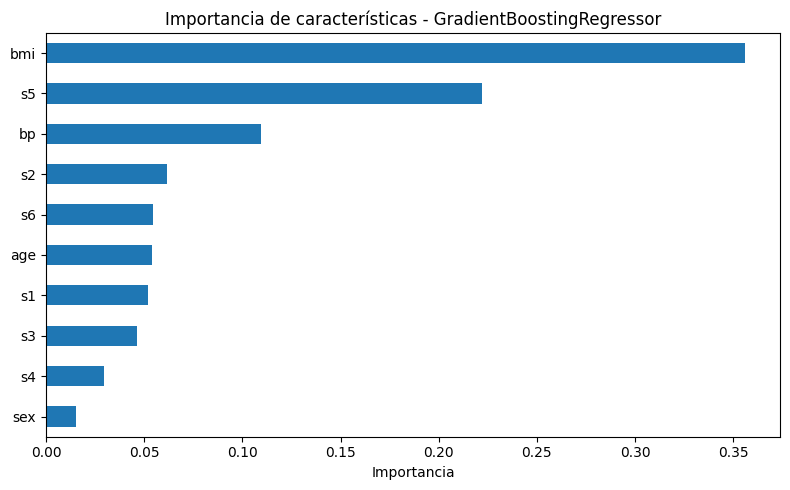

In [16]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Ejemplo completo de regresión con Gradient Boosting (sklearn) usando el dataset "diabetes"
import matplotlib.pyplot as plt

# Cargar datos
data = load_diabetes()
X = data.data
y = data.target
feature_names = data.feature_names

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Escalado de características (recomendado)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Definir y entrenar el modelo Gradient Boosting (regresión)
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
gb.fit(X_train_s, y_train)

# Predicción y métricas
y_pred = gb.predict(X_test_s)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.3f}    RMSE: {rmse:.3f}    R2: {r2:.3f}")

# Gráfica: True vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("True vs Predicted - GradientBoostingRegressor")
plt.grid(True)
plt.show()

# Histograma de residuos
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("Residuo (y_true - y_pred)")
plt.title("Histograma de residuos")
plt.show()

# Importancias de características
fi = gb.feature_importances_
fi_series = pd.Series(fi, index=feature_names).sort_values(ascending=True)
plt.figure(figsize=(8,5))
fi_series.plot.barh()
plt.title("Importancia de características - GradientBoostingRegressor")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

---

## XGBoost (Extreme Gradient Boosting)
XGBoost es una implementación avanzada del gradient boosting que lleva esta metodología un paso más allá.
- **Gradientes de Segundo Orden**: XGBoost utiliza aproximaciones más detalladas al calcular los gradientes de segundo orden de la función de pérdida para minimizarla.

- **Regularización Avanzada**: Incorpora técnicas de regularización avanzada (L1 y L2) para reducir el sobreajuste (overfitting), lo que mejora el rendimiento y la capacidad de generalización del modelo.
- **Modelo Destacado**: Tanto XGBoost como LightGBM son modelos basados en árboles que han demostrado en ciertos casos ser capaces de superar incluso a las redes neuronales

/home/patricio/Documentos/github/ciencia-de-datos/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [19:56:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9650
ROC AUC: 0.9943

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        53
           1       0.96      0.99      0.97        90

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143

Confusion Matrix:
[[49  4]
 [ 1 89]]


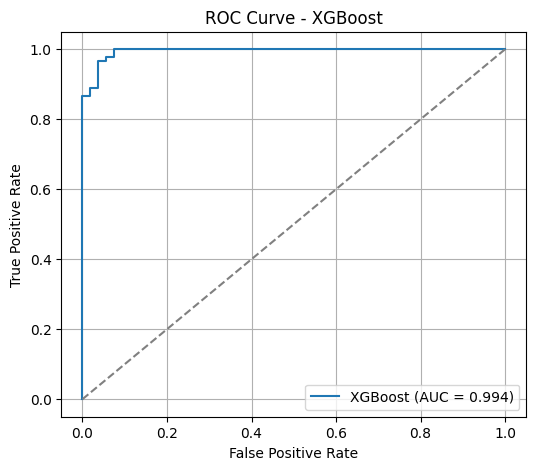

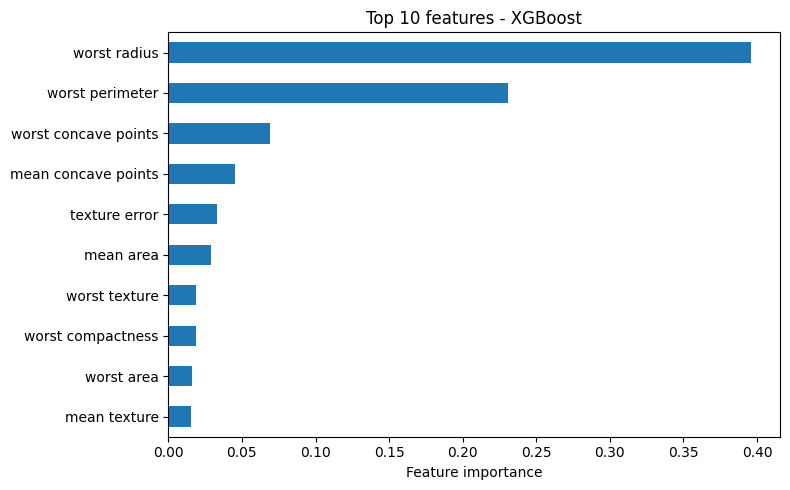

In [18]:
# Ejemplo completo de clasificación con XGBoost (sklearn API) usando el dataset breast cancer
import sys
import subprocess
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Intentar importar xgboost, instalar si no está disponible
#try:
#except Exception:
#    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)


# Cargar datos
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# División train/test (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Escalado (recomendado para XGBoost no es obligatorio, pero es útil para comparativas)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Definir el clasificador XGBoost (sklearn wrapper)
clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    use_label_encoder=False,  # evita warning en versiones recientes
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

# Entrenar con early stopping monitorizando el conjunto de validación (test)
# Algunas versiones del wrapper sklearn de XGBoost no aceptan `callbacks` en fit().
# Usamos el argumento compatible `early_stopping_rounds` en su lugar.
clf.fit(
    X_train_s,
    y_train,
    eval_set=[(X_test_s, y_test)],
    verbose=False,
)

# Predicciones y probabilidades
y_pred = clf.predict(X_test_s)
y_proba = clf.predict_proba(X_test_s)[:, 1]

# Métricas de evaluación
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC: {roc_auc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(True)
plt.show()

# Importancias de características (top 10)
importances = clf.feature_importances_
idxs = np.argsort(importances)[::-1][:10]
top_feats = feature_names[idxs]
top_vals = importances[idxs]

pd.Series(top_vals, index=top_feats).sort_values().plot.barh(figsize=(8,5))
plt.title("Top 10 features - XGBoost")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

Random Forest

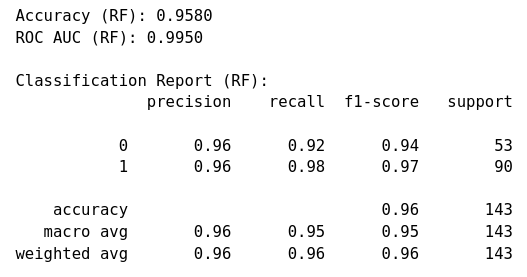

Gradient boosting

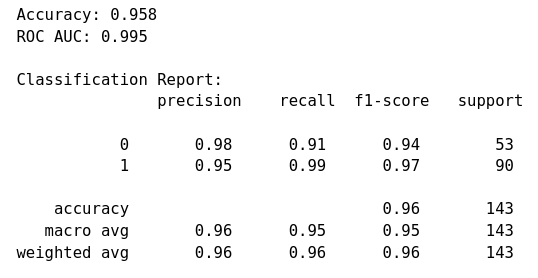

XGBoost

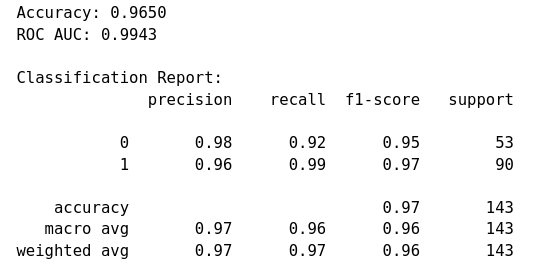